In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import pyodbc

In [2]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=Northwind;"
    "Trusted_Connection=yes;"
)

# Import supplier_ranking query from SQL files in dir
cohort_sql = Path("cohort_analysis.sql").read_text()
cohort_sql = pd.read_sql(cohort_sql, conn)

conn.close()

C:\Users\chris\AppData\Local\Temp\ipykernel_33128\2231503313.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cohort_sql = pd.read_sql(cohort_sql, conn)


In [ ]:
-- USE Northwind;
-- GO

WITH FirstPurchase AS (
    SELECT
        CustomerID,
        DATEFROMPARTS(YEAR(MIN(OrderDate)), MONTH(MIN(OrderDate)), 1) AS CohortMonth
    FROM Orders
    WHERE OrderDate IS NOT NULL
    GROUP BY CustomerID
),
CustomerActivity AS (
    SELECT
        fp.CustomerID,
        fp.CohortMonth,
        DATEFROMPARTS(YEAR(o.OrderDate), MONTH(o.OrderDate), 1) AS OrderMonth,
        DATEDIFF(MONTH, fp.CohortMonth,
            DATEFROMPARTS(YEAR(o.OrderDate), MONTH(o.OrderDate), 1)) AS MonthsElapsed
    FROM FirstPurchase fp
    JOIN Orders o ON fp.CustomerID = o.CustomerID
    WHERE o.OrderDate IS NOT NULL
),
CohortSize AS (
    SELECT CohortMonth, COUNT(DISTINCT CustomerID) AS TotalCustomers
    FROM FirstPurchase
    GROUP BY CohortMonth
)
SELECT
    ca.CohortMonth,
    cs.TotalCustomers                                           AS CohortSize,
    ca.MonthsElapsed,
    COUNT(DISTINCT ca.CustomerID)                              AS ActiveCustomers,
    ROUND(100.0 * COUNT(DISTINCT ca.CustomerID)
        / cs.TotalCustomers,2)                               AS RetentionRate
FROM CustomerActivity ca
JOIN CohortSize cs ON ca.CohortMonth = cs.CohortMonth
WHERE ca.MonthsElapsed BETWEEN 0 AND 6
GROUP BY ca.CohortMonth, cs.TotalCustomers, ca.MonthsElapsed
ORDER BY ca.CohortMonth, ca.MonthsElapsed;


## Cohort Analysis SQL Logic

The SQL query above performs a customer cohort retention analysis with the following steps:

1. **FirstPurchase CTE** – Identifies each customer's first purchase date and truncates it to the first day of that month (the cohort month).

2. **CustomerActivity CTE** – Joins the original orders to each customer's cohort, calculating the number of months elapsed between the cohort month and each subsequent order month.

3. **CohortSize CTE** – Counts the total number of unique customers in each cohort month.

4. **Final SELECT** – For each cohort month and each month elapsed (0 to 6 months), it calculates:
   - `CohortSize` – Total customers in that cohort
   - `ActiveCustomers` – Customers who made a purchase in that period
   - `RetentionRate` – Percentage of customers who remained active (ActiveCustomers / CohortSize × 100)

The `WHERE ca.MonthsElapsed BETWEEN 0 AND 6` limits the analysis to the first 6 months after each customer's first purchase, which is typically the most telling period for retention patterns.

In [4]:
print(cohort_sql.head(10))

  CohortMonth  CohortSize  MonthsElapsed  ActiveCustomers  RetentionRate
0  1996-07-01          20              0               20         100.00
1  1996-07-01          20              1                4          20.00
2  1996-07-01          20              2                4          20.00
3  1996-07-01          20              3                4          20.00
4  1996-07-01          20              4                4          20.00
5  1996-07-01          20              5                6          30.00
6  1996-07-01          20              6                7          35.00
7  1996-08-01          14              0               14         100.00
8  1996-08-01          14              1                6          42.86
9  1996-08-01          14              2                4          28.57


## Raw Retention Data Interpretation

The table above shows the following structure:

- **CohortMonth** – The month of the customer's first purchase (e.g., July 1996, August 1996)
- **CohortSize** – Number of new customers acquired that month
- **MonthsElapsed** – How many months after first purchase (0 = first purchase month)
- **ActiveCustomers** – Number of customers from that cohort who purchased in that period
- **RetentionRate** – Percentage retention (ActiveCustomers / CohortSize × 100)

**Key observations from the raw data:**
- July 1996 cohort had 20 new customers. Retention dropped sharply from 100% (Month 0) to 20% (Month 1), then gradually recovered to 35% by Month 6.
- August 1996 cohort had 14 new customers with a stronger initial retention of 42.86% at Month 1, though it declined to 28.57% by Month 2.

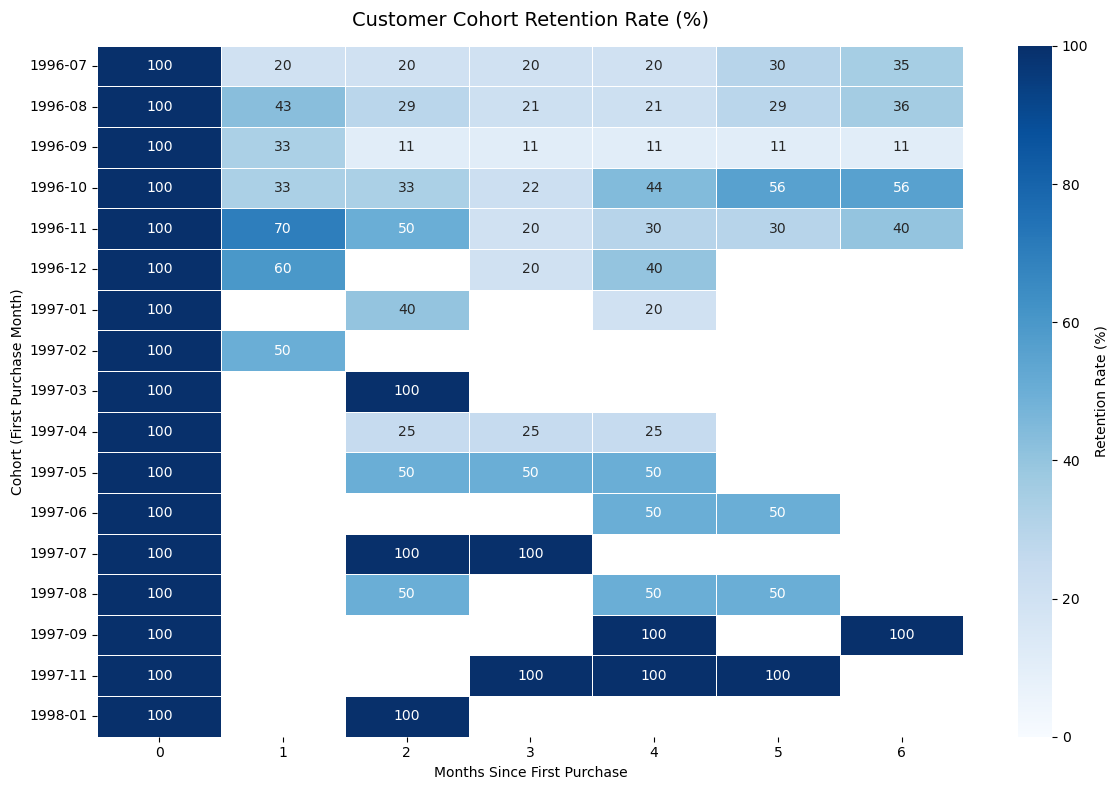

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = cohort_sql # the T-SQL above

# Pivot: rows = cohort month, columns = months elapsed, values = retention rate
cohort_pivot = df.pivot_table(
    index='CohortMonth',
    columns='MonthsElapsed',
    values='RetentionRate'
)

# Format cohort month labels for readability
cohort_pivot.index = pd.to_datetime(cohort_pivot.index).strftime('%Y-%m')

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    vmin=0, vmax=100,
    cbar_kws={'label': 'Retention Rate (%)'}
)
plt.title('Customer Cohort Retention Rate (%)', fontsize=14, pad=15)
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Cohort Retention Heatmap Analysis

The heatmap above visualizes customer retention rates across different cohorts over time.

### How to Read This Chart:
- **Rows** represent customer cohorts (the month they made their first purchase)
- **Columns** represent months since the first purchase (0 to 6)
- **Color intensity** (darker = higher retention percentage)
- **Numbers** show the exact retention rate for each cohort at each interval

### Key Business Insights:

1. **Initial Drop-off is Severe** – All cohorts show a dramatic decline from Month 0 (100%) to Month 1 (20–43%). This indicates that while initial acquisition is successful, the first post-purchase month is critical for customer churn.

2. **July 1996 Cohort Performance** – This cohort (20 customers) started strong but dropped to 20% by Month 1. However, retention improved to 30% by Month 5 and 35% by Month 6, suggesting that re-engagement efforts or seasonal factors may have brought customers back.

3. **August 1996 Cohort** – Though smaller (14 customers), this cohort showed better initial retention (42.86%) at Month 1, indicating potentially higher-quality acquisitions or a more engaging onboarding experience.

4. **Long-term Retention Trends** – Cohorts tend to stabilize between 20–35% after Month 2, suggesting that customers who remain beyond the second month are more likely to become loyal, repeat purchasers.

### Recommended Actions:
- Investigate what changed between July and August 1996 that improved Month 1 retention.
- Implement targeted win-back campaigns for customers who haven't purchased since their first month.
- Analyze the behavior of customers who remain active at Month 6 vs. those who churn early to identify key retention drivers.